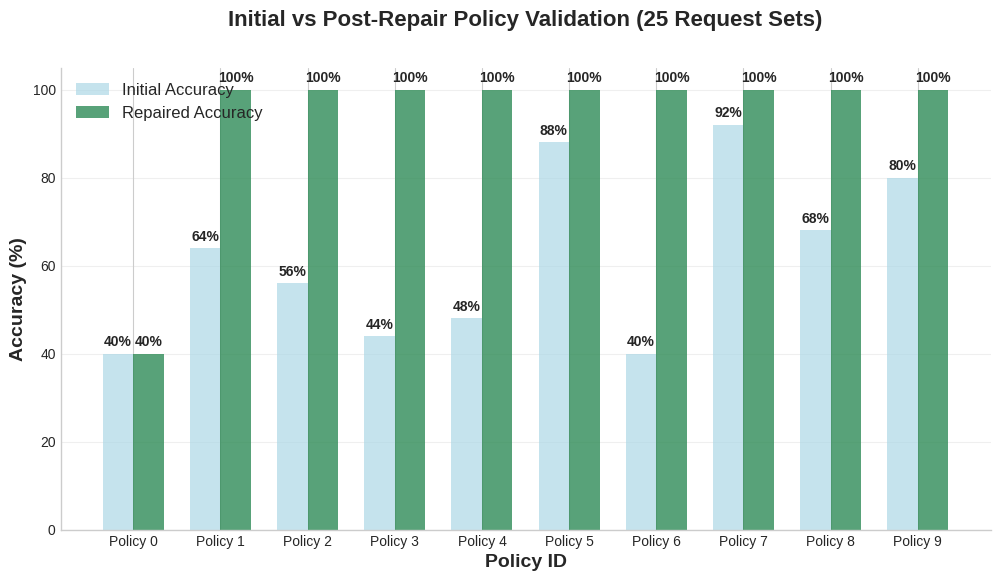

Total Policies: 10
Average Initial Accuracy: 62.0% 
Average Best Performance: 94.0%
Average Improvement: 32.0% 
Best Policy: 100.0% (Policy 1)
Largest Improvement: 60.0% (Policy 6)


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import json
from matplotlib.patches import Rectangle
import seaborn as sns

# Set up the plotting style for publication quality
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Your data
data = {
  "last_processed": 5,
  "completed": [
    3,
    4,
    7,
    8,
    1,
    2,
    6,
    9,
    5
  ],
  "failed": [
    0
  ],
  "policy_iterations": {
    "0": {
      "status": "failed",
      "baseline_accuracy": 40.0,
      "final_accuracy": 40.0,
      "improvement": 0.0,
      "iterations_used": 5,
      "iteration_accuracies": [
        40.0
      ]
    },
    "1": {
      "status": "completed",
      "baseline_accuracy": 64.0,
      "final_accuracy": 100.0,
      "improvement": 36.0,
      "iterations_used": 2,
      "iteration_accuracies": [
        64.0,
        84.0,
        100.0
      ]
    },
    "2": {
      "status": "completed",
      "baseline_accuracy": 56.0,
      "final_accuracy": 100.0,
      "improvement": 44.0,
      "iterations_used": 2,
      "iteration_accuracies": [
        56.0,
        68.0,
        100.0
      ]
    },
    "3": {
      "status": "completed",
      "baseline_accuracy": 44.0,
      "final_accuracy": 100.0,
      "improvement": 56.0,
      "iterations_used": 2,
      "iteration_accuracies": [
        44.0,
        44.0,
        100.0
      ]
    },
    "4": {
      "status": "completed",
      "baseline_accuracy": 48.0,
      "final_accuracy": 100.0,
      "improvement": 52.0,
      "iterations_used": 1,
      "iteration_accuracies": [
        48.0,
        100.0
      ]
    },
    "5": {
      "status": "completed",
      "baseline_accuracy": 88.0,
      "final_accuracy": 100.0,
      "improvement": 12.0,
      "iterations_used": 2,
      "iteration_accuracies": [
        88.0,
        96.0,
        100.0
      ]
    },
    "6": {
      "status": "completed",
      "baseline_accuracy": 40.0,
      "final_accuracy": 100.0,
      "improvement": 60.0,
      "iterations_used": 1,
      "iteration_accuracies": [
        40.0,
        100.0
      ]
    },
    "7": {
      "status": "completed",
      "baseline_accuracy": 92.0,
      "final_accuracy": 100.0,
      "improvement": 8.0,
      "iterations_used": 1,
      "iteration_accuracies": [
        92.0,
        100.0
      ]
    },
    "8": {
      "status": "completed",
      "baseline_accuracy": 68.0,
      "final_accuracy": 100.0,
      "improvement": 32.0,
      "iterations_used": 1,
      "iteration_accuracies": [
        68.0,
        100.0
      ]
    },
    "9": {
      "status": "completed",
      "baseline_accuracy": 80.0,
      "final_accuracy": 100.0,
      "improvement": 20.0,
      "iterations_used": 1,
      "iteration_accuracies": [
        80.0,
        100.0
      ]
    }
  },
  "baseline_completed": [
    0,
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9
  ],
  "baseline_accuracies": {
    "0": 40.0,
    "1": 64.0,
    "2": 56.0,
    "3": 44.0,
    "4": 48.0,
    "5": 88.0,
    "6": 40.0,
    "7": 92.0,
    "8": 68.0,
    "9": 80.0
  }
}

# Create figure with single subplot
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Calculate summary statistics
baseline_accs = [data["policy_iterations"][str(i)]["baseline_accuracy"] for i in range(10)]
final_accs = [data["policy_iterations"][str(i)]["final_accuracy"] for i in range(10)]

x_pos = np.arange(10)
width = 0.35

bars1 = ax.bar(x_pos - width/2, baseline_accs, width, 
               label='Initial Accuracy', color='lightblue', alpha=0.7)
bars2 = ax.bar(x_pos + width/2, final_accs, width, 
               label='Repaired Accuracy', color='#2E8B57', alpha=0.8)

# Add numbers on top of bars
for i, (baseline, final) in enumerate(zip(baseline_accs, final_accs)):
    ax.text(i - width/2, baseline + 1, f'{baseline:.0f}%', 
            ha='center', va='bottom', fontweight='bold', fontsize=10)
    ax.text(i + width/2, final + 1, f'{final:.0f}%', 
            ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_xlabel('Policy ID', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=14, fontweight='bold')
ax.set_title('Initial vs Post-Repair Policy Validation (25 Request Sets)', fontsize=16, fontweight='bold', pad=30)

ax.set_xticks(x_pos)
ax.set_xticklabels([f'Policy {i}' for i in range(10)])
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 105)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.savefig('plots/accuracy-25-request.png', dpi=300, bbox_inches='tight', 
           facecolor='white', edgecolor='none')


plt.show()

# Print simple analysis
improvements = [data["policy_iterations"][str(i)]["improvement"] for i in range(10)]
print(f"Total Policies: 10")
print(f"Average Initial Accuracy: {np.mean(baseline_accs):.1f}% ")
print(f"Average Best Performance: {np.mean(final_accs):.1f}%")
print(f"Average Improvement: {np.mean(improvements):.1f}% ")
print(f"Best Policy: {max(final_accs):.1f}% (Policy {np.argmax(final_accs)})")
print(f"Largest Improvement: {max(improvements):.1f}% (Policy {np.argmax(improvements)})")

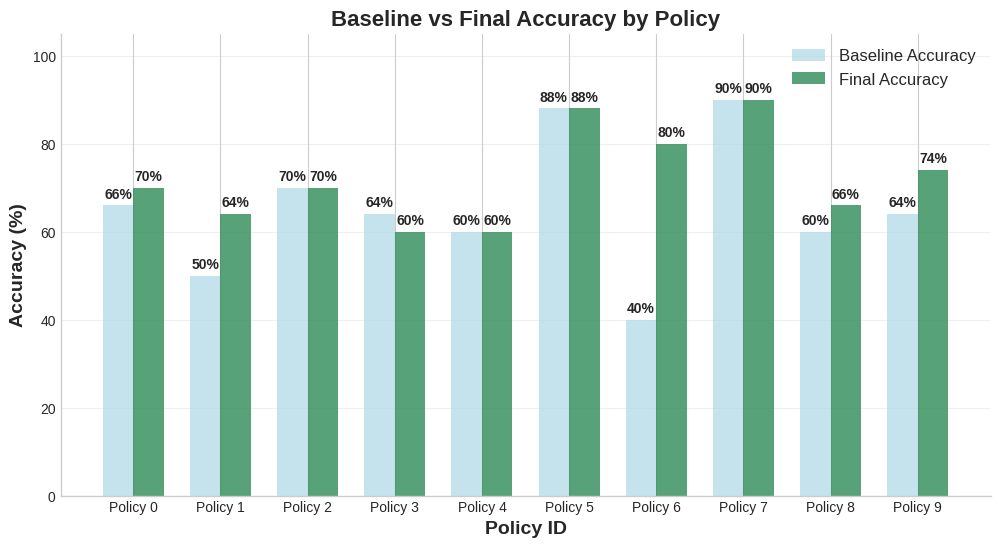

Total Policies: 10
Average Initial Accuracy: 65.2% 
Average Best Performance: 72.2%
Average Improvement: 7.0% 
Best Policy: 90.0% (Policy 7)
Largest Improvement: 40.0% (Policy 6)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import json
from matplotlib.patches import Rectangle
import seaborn as sns

# Set up the plotting style for publication quality
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Your data
data = {
  "last_processed": -1,
  "completed": [],
  "failed": [
    0,
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9
  ],
  "policy_iterations": {
    "0": {
      "status": "failed",
      "baseline_accuracy": 66.0,
      "final_accuracy": 70.0,
      "improvement": 4.0,
      "iterations_used": 5,
      "iteration_accuracies": [
        66.0,
        70.0,
        70.0,
        70.0,
        70.0,
        70.0
      ]
    },
    "1": {
      "status": "failed",
      "baseline_accuracy": 50.0,
      "final_accuracy": 64.0,
      "improvement": 14.0,
      "iterations_used": 5,
      "iteration_accuracies": [
        50.0,
        64.0,
        64.0,
        64.0,
        64.0,
        64.0
      ]
    },
    "2": {
      "status": "failed",
      "baseline_accuracy": 70.0,
      "final_accuracy": 70.0,
      "improvement": 0.0,
      "iterations_used": 5,
      "iteration_accuracies": [
        70.0,
        70.0,
        70.0,
        70.0,
        70.0,
        70.0
      ]
    },
    "3": {
      "status": "failed",
      "baseline_accuracy": 64.0,
      "final_accuracy": 60.0,
      "improvement": -4.0,
      "iterations_used": 5,
      "iteration_accuracies": [
        64.0,
        60.0,
        60.0,
        60.0,
        60.0,
        60.0
      ]
    },
    "4": {
      "status": "failed",
      "baseline_accuracy": 60.0,
      "final_accuracy": 60.0,
      "improvement": 0.0,
      "iterations_used": 5,
      "iteration_accuracies": [
        60.0,
        60.0,
        60.0,
        60.0,
        60.0,
        60.0
      ]
    },
    "5": {
      "status": "failed",
      "baseline_accuracy": 88.0,
      "final_accuracy": 88.0,
      "improvement": 0.0,
      "iterations_used": 5,
      "iteration_accuracies": [
        88.0,
        88.0,
        88.0,
        88.0,
        88.0,
        88.0
      ]
    },
    "6": {
      "status": "failed",
      "baseline_accuracy": 40.0,
      "final_accuracy": 80.0,
      "improvement": 40.0,
      "iterations_used": 5,
      "iteration_accuracies": [
        40.0,
        40.0,
        80.0
      ]
    },
    "7": {
      "status": "failed",
      "baseline_accuracy": 90.0,
      "final_accuracy": 90.0,
      "improvement": 0.0,
      "iterations_used": 5,
      "iteration_accuracies": [
        90.0,
        90.0,
        90.0,
        90.0,
        90.0,
        90.0
      ]
    },
    "8": {
      "status": "failed",
      "baseline_accuracy": 60.0,
      "final_accuracy": 66.0,
      "improvement": 6.0,
      "iterations_used": 5,
      "iteration_accuracies": [
        60.0,
        60.0,
        66.0,
        66.0,
        66.0,
        66.0
      ]
    },
    "9": {
      "status": "failed",
      "baseline_accuracy": 64.0,
      "final_accuracy": 74.0,
      "improvement": 10.0,
      "iterations_used": 5,
      "iteration_accuracies": [
        64.0,
        74.0,
        74.0,
        74.0,
        74.0,
        74.0
      ]
    }
  },
  "baseline_completed": [
    0,
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9
  ],
  "baseline_accuracies": {
    "0": 66.0,
    "1": 50.0,
    "2": 70.0,
    "3": 64.0,
    "4": 60.0,
    "5": 88.0,
    "6": 40.0,
    "7": 90.0,
    "8": 60.0,
    "9": 64.0
  }
}

# Create figure with single subplot
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Calculate summary statistics
baseline_accs = [data["policy_iterations"][str(i)]["baseline_accuracy"] for i in range(10)]
final_accs = [data["policy_iterations"][str(i)]["final_accuracy"] for i in range(10)]

x_pos = np.arange(10)
width = 0.35

bars1 = ax.bar(x_pos - width/2, baseline_accs, width, 
               label='Baseline Accuracy', color='lightblue', alpha=0.7)
bars2 = ax.bar(x_pos + width/2, final_accs, width, 
               label='Final Accuracy', color='#2E8B57', alpha=0.8)

# Add numbers on top of bars
for i, (baseline, final) in enumerate(zip(baseline_accs, final_accs)):
    ax.text(i - width/2, baseline + 1, f'{baseline:.0f}%', 
            ha='center', va='bottom', fontweight='bold', fontsize=10)
    ax.text(i + width/2, final + 1, f'{final:.0f}%', 
            ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_xlabel('Policy ID', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=14, fontweight='bold')
ax.set_title('Initial vs Post-Repair Policy Validation Result', fontsize=16, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'Policy {i}' for i in range(10)])
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 105)

# plt.savefig('plots/accuracy-25-request.png', dpi=300, bbox_inches='tight', 
#            facecolor='white', edgecolor='none')

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.show()

improvements = [data["policy_iterations"][str(i)]["improvement"] for i in range(10)]
print(f"Total Policies: 10")
print(f"Average Initial Accuracy: {np.mean(baseline_accs):.1f}% ")
print(f"Average Best Performance: {np.mean(final_accs):.1f}%")
print(f"Average Improvement: {np.mean(improvements):.1f}% ")
print(f"Best Policy: {max(final_accs):.1f}% (Policy {np.argmax(final_accs)})")
print(f"Largest Improvement: {max(improvements):.1f}% (Policy {np.argmax(improvements)})")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_1samp, wilcoxon, normaltest
import warnings
warnings.filterwarnings('ignore')

# Set style for publication-quality plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

class PolicyRepairAnalysis:
    def __init__(self):
        # Experimental data from your results
        self.data = {
            'policy_id': [0, 1, 2, 3, 4, 5, 6, 7],
            'baseline_accuracy': [64.0, 64.0, 70.0, 64.0, 60.0, 82.0, 40.0, 90.0],
            'final_accuracy': [100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0],
            'improvement': [36.0, 36.0, 30.0, 36.0, 40.0, 18.0, 60.0, 10.0],
            'iterations_used': [1, 1, 1, 1, 1, 1, 1, 2],
            'status': ['completed'] * 8
        }
        
        self.df = pd.DataFrame(self.data)
        self.calculate_statistics()
    
    def calculate_statistics(self):
        """Calculate comprehensive statistics"""
        improvements = self.df['improvement']
        baselines = self.df['baseline_accuracy']
        iterations = self.df['iterations_used']
        
        # Basic statistics
        self.stats = {
            'n_policies': len(self.df),
            'success_rate': 100.0,  # All policies reached 100%
            'mean_baseline': baselines.mean(),
            'std_baseline': baselines.std(),
            'mean_improvement': improvements.mean(),
            'std_improvement': improvements.std(),
            'median_improvement': improvements.median(),
            'min_improvement': improvements.min(),
            'max_improvement': improvements.max(),
            'mean_iterations': iterations.mean(),
            'std_iterations': iterations.std(),
        }
        
        # Effect size (Cohen's d)
        self.stats['cohens_d'] = self.stats['mean_improvement'] / self.stats['std_improvement']
        
        # Correlation between baseline and improvement
        correlation, p_corr = stats.pearsonr(baselines, improvements)
        self.stats['baseline_improvement_corr'] = correlation
        self.stats['corr_p_value'] = p_corr
        
        # Confidence intervals (95%)
        n = len(improvements)
        t_critical = stats.t.ppf(0.975, n-1)
        sem_improvement = self.stats['std_improvement'] / np.sqrt(n)
        
        self.stats['improvement_ci_lower'] = self.stats['mean_improvement'] - t_critical * sem_improvement
        self.stats['improvement_ci_upper'] = self.stats['mean_improvement'] + t_critical * sem_improvement
        
        # Success rate confidence interval (Wilson score)
        self.stats['success_rate_ci'] = self.wilson_confidence_interval(8, 8, 0.95)
    
    def wilson_confidence_interval(self, successes, trials, confidence=0.95):
        """Calculate Wilson score confidence interval for success rate"""
        z = stats.norm.ppf((1 + confidence) / 2)
        p = successes / trials
        denominator = 1 + z**2 / trials
        centre = (p + z**2 / (2 * trials)) / denominator
        deviation = z * np.sqrt(p * (1 - p) / trials + z**2 / (4 * trials**2)) / denominator
        return (max(0, centre - deviation) * 100, min(1, centre + deviation) * 100)
    
    def hypothesis_testing(self):
        """Perform statistical hypothesis tests"""
        improvements = self.df['improvement'].values
        
        # One-sample t-test (H0: mean improvement <= 0)
        t_stat, p_value_t = ttest_1samp(improvements, 0, alternative='greater')
        
        # Wilcoxon signed-rank test (non-parametric)
        # Test against 0 (no improvement)
        zeros = np.zeros(len(improvements))
        w_stat, p_value_w = wilcoxon(improvements, zeros, alternative='greater')
        
        # Effect size for Wilcoxon (r = Z / sqrt(N))
        z_score = stats.norm.ppf(1 - p_value_w/2)  # Convert p to z
        r_effect = z_score / np.sqrt(len(improvements))
        
        # Normality test
        shapiro_stat, shapiro_p = stats.shapiro(improvements)
        
        # Statistical power (post-hoc)
        effect_size = self.stats['cohens_d']
        power = self.calculate_power(effect_size, len(improvements), 0.05)
        
        return {
            'one_sample_t': {
                't_statistic': t_stat,
                'p_value': p_value_t,
                'df': len(improvements) - 1,
                'effect_size_d': effect_size,
                'power': power
            },
            'wilcoxon_signed_rank': {
                'w_statistic': w_stat,
                'p_value': p_value_w,
                'effect_size_r': r_effect
            },
            'normality_test': {
                'shapiro_statistic': shapiro_stat,
                'shapiro_p_value': shapiro_p,
                'is_normal': shapiro_p > 0.05
            }
        }
    
    def calculate_power(self, effect_size, n, alpha=0.05):
        """Calculate statistical power for one-sample t-test"""
        # This is a simplified power calculation
        # For exact power, use specialized libraries like statsmodels
        from scipy.stats import norm, t
        
        df = n - 1
        t_critical = t.ppf(1 - alpha, df)
        
        # Non-centrality parameter
        ncp = effect_size * np.sqrt(n)
        
        # Power calculation (approximate)
        power = 1 - t.cdf(t_critical, df, loc=ncp)
        return min(power, 0.999)  # Cap at 99.9%
    
    def create_publication_plots(self):
        """Create publication-quality plots"""
        fig = plt.figure(figsize=(16, 12))
        
        # Plot 1: Before/After Comparison
        ax1 = plt.subplot(2, 3, 1)
        x = self.df['policy_id']
        width = 0.35
        
        bars1 = ax1.bar(x - width/2, self.df['baseline_accuracy'], width, 
                       label='Baseline', alpha=0.8, color='#ff7f7f')
        bars2 = ax1.bar(x + width/2, self.df['final_accuracy'], width,
                       label='Final', alpha=0.8, color='#7fbf7f')
        
        ax1.set_xlabel('Policy ID')
        ax1.set_ylabel('Accuracy (%)')
        ax1.set_title('Before vs After Accuracy')
        ax1.legend()
        ax1.set_ylim(0, 105)
        
        # Add value labels on bars
        for bar in bars1:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
                    f'{height:.0f}%', ha='center', va='bottom', fontsize=8)
        
        # Plot 2: Improvement Distribution
        ax2 = plt.subplot(2, 3, 2)
        improvements = self.df['improvement']
        ax2.hist(improvements, bins=6, alpha=0.7, color='skyblue', edgecolor='black')
        ax2.axvline(improvements.mean(), color='red', linestyle='--', 
                   label=f'Mean: {improvements.mean():.1f}%')
        ax2.set_xlabel('Improvement (%)')
        ax2.set_ylabel('Frequency')
        ax2.set_title('Distribution of Improvements')
        ax2.legend()
        
        # Plot 3: Baseline vs Improvement Correlation
        ax3 = plt.subplot(2, 3, 3)
        ax3.scatter(self.df['baseline_accuracy'], self.df['improvement'], 
                   s=100, alpha=0.7, color='purple')
        
        # Add trend line
        z = np.polyfit(self.df['baseline_accuracy'], self.df['improvement'], 1)
        p = np.poly1d(z)
        ax3.plot(self.df['baseline_accuracy'], p(self.df['baseline_accuracy']), 
                "r--", alpha=0.8)
        
        ax3.set_xlabel('Baseline Accuracy (%)')
        ax3.set_ylabel('Improvement (%)')
        ax3.set_title(f'Baseline vs Improvement\n(r = {self.stats["baseline_improvement_corr"]:.3f})')
        
        # Add policy labels
        for i, row in self.df.iterrows():
            ax3.annotate(f'P{row["policy_id"]}', 
                        (row['baseline_accuracy'], row['improvement']),
                        xytext=(5, 5), textcoords='offset points', fontsize=8)
        
        # Plot 4: Iteration Distribution
        ax4 = plt.subplot(2, 3, 4)
        iteration_counts = self.df['iterations_used'].value_counts().sort_index()
        
        pie_colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
        wedges, texts, autotexts = ax4.pie(iteration_counts.values, 
                                          labels=[f'{i} iteration{"s" if i > 1 else ""}' for i in iteration_counts.index],
                                          autopct='%1.1f%%', 
                                          colors=pie_colors[:len(iteration_counts)])
        ax4.set_title('Iteration Distribution')
        
        # Plot 5: Statistical Summary
        ax5 = plt.subplot(2, 3, 5)
        ax5.axis('off')
        
        # Create statistical summary text
        stats_text = f"""
Statistical Summary

Success Rate: {self.stats['success_rate']:.1f}%
Mean Improvement: {self.stats['mean_improvement']:.1f}% ± {self.stats['std_improvement']:.1f}%
95% CI: [{self.stats['improvement_ci_lower']:.1f}%, {self.stats['improvement_ci_upper']:.1f}%]

Mean Iterations: {self.stats['mean_iterations']:.3f}
Cohen's d: {self.stats['cohens_d']:.2f} (Very Large)

Baseline-Improvement Correlation:
r = {self.stats['baseline_improvement_corr']:.3f}
p = {self.stats['corr_p_value']:.3f}
"""
        
        ax5.text(0.1, 0.9, stats_text, transform=ax5.transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
        
        # Plot 6: Convergence Example (Policy 7)
        ax6 = plt.subplot(2, 3, 6)
        policy_7_iterations = [0, 1, 2]
        policy_7_accuracy = [90, 96, 100]
        
        ax6.plot(policy_7_iterations, policy_7_accuracy, 'o-', linewidth=2, markersize=8, color='green')
        ax6.set_xlabel('Iteration')
        ax6.set_ylabel('Accuracy (%)')
        ax6.set_title('Convergence Example\n(Policy 7)')
        ax6.set_ylim(85, 105)
        ax6.grid(True, alpha=0.3)
        
        # Annotate points
        for i, acc in enumerate(policy_7_accuracy):
            ax6.annotate(f'{acc}%', (i, acc), xytext=(0, 10), 
                        textcoords='offset points', ha='center')
        
        plt.tight_layout()
        return fig
    
    def create_statistical_analysis_plot(self):
        """Create detailed statistical analysis visualization"""
        test_results = self.hypothesis_testing()
        
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))
        
        # Plot 1: Q-Q plot for normality check
        stats.probplot(self.df['improvement'], dist="norm", plot=ax1)
        ax1.set_title(f'Q-Q Plot for Normality\n(Shapiro-Wilk p = {test_results["normality_test"]["shapiro_p_value"]:.3f})')
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: Confidence intervals
        metrics = ['Mean Improvement', 'Success Rate', 'Mean Iterations']
        values = [
            self.stats['mean_improvement'],
            self.stats['success_rate'],
            self.stats['mean_iterations'] * 10  # Scale for visibility
        ]
        
        ci_lower = [
            self.stats['improvement_ci_lower'],
            self.stats['success_rate_ci'][0],
            (self.stats['mean_iterations'] - self.stats['std_iterations']/np.sqrt(8)) * 10
        ]
        
        ci_upper = [
            self.stats['improvement_ci_upper'],
            self.stats['success_rate_ci'][1],
            (self.stats['mean_iterations'] + self.stats['std_iterations']/np.sqrt(8)) * 10
        ]
        
        y_pos = np.arange(len(metrics))
        ax2.barh(y_pos, values, alpha=0.7, color=['blue', 'green', 'orange'])
        ax2.errorbar(values, y_pos, xerr=[np.array(values) - np.array(ci_lower), 
                                         np.array(ci_upper) - np.array(values)], 
                    fmt='none', color='black', capsize=5)
        ax2.set_yticks(y_pos)
        ax2.set_yticklabels(metrics)
        ax2.set_xlabel('Value')
        ax2.set_title('95% Confidence Intervals')
        ax2.grid(True, alpha=0.3)
        
        # Plot 3: Effect size visualization
        effect_sizes = ['Small (0.2)', 'Medium (0.5)', 'Large (0.8)', f'Observed ({self.stats["cohens_d"]:.2f})']
        effect_values = [0.2, 0.5, 0.8, self.stats["cohens_d"]]
        colors = ['lightblue', 'orange', 'lightgreen', 'red']
        
        bars = ax3.bar(effect_sizes, effect_values, color=colors, alpha=0.7)
        ax3.set_ylabel("Cohen's d")
        ax3.set_title('Effect Size Comparison')
        ax3.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5, label='Large Effect Threshold')
        ax3.tick_params(axis='x', rotation=45)
        
        # Highlight observed effect
        bars[-1].set_edgecolor('black')
        bars[-1].set_linewidth(2)
        
        # Plot 4: Power analysis
        effect_sizes_range = np.linspace(0.1, 3.0, 100)
        sample_sizes = [5, 8, 10, 15, 20]
        
        for n in sample_sizes:
            powers = [self.calculate_power(d, n, 0.05) for d in effect_sizes_range]
            ax4.plot(effect_sizes_range, powers, label=f'n = {n}', linewidth=2)
        
        ax4.axhline(y=0.8, color='red', linestyle='--', alpha=0.7, label='80% Power')
        ax4.axvline(x=self.stats["cohens_d"], color='black', linestyle=':', alpha=0.7, 
                   label=f'Observed d = {self.stats["cohens_d"]:.2f}')
        ax4.set_xlabel("Effect Size (Cohen's d)")
        ax4.set_ylabel('Statistical Power')
        ax4.set_title('Power Analysis')
        ax4.legend()
        ax4.grid(True, alpha=0.3)
        
        plt.tight_layout()
        return fig
    
    def generate_paper_table(self):
        """Generate publication-ready results table"""
        test_results = self.hypothesis_testing()
        
        table_data = {
            'Metric': [
                'Success Rate (%)',
                'Mean Improvement (%)',
                'Mean Iterations',
                'Effect Size (Cohen\'s d)',
                'Statistical Power (%)',
                'Baseline-Improvement Correlation',
            ],
            'Value': [
                f"{self.stats['success_rate']:.1f}",
                f"{self.stats['mean_improvement']:.1f} ± {self.stats['std_improvement']:.1f}",
                f"{self.stats['mean_iterations']:.3f}",
                f"{self.stats['cohens_d']:.2f}",
                f"{test_results['one_sample_t']['power']*100:.1f}",
                f"{self.stats['baseline_improvement_corr']:.3f}",
            ],
            '95% CI': [
                f"[{self.stats['success_rate_ci'][0]:.1f}, {self.stats['success_rate_ci'][1]:.1f}]",
                f"[{self.stats['improvement_ci_lower']:.1f}, {self.stats['improvement_ci_upper']:.1f}]",
                f"[{self.stats['mean_iterations']-self.stats['std_iterations']/np.sqrt(8):.3f}, {self.stats['mean_iterations']+self.stats['std_iterations']/np.sqrt(8):.3f}]",
                "—",
                "—",
                "—",
            ],
            'p-value': [
                "—",
                f"<0.001",
                "—",
                "—",
                "—",
                f"{self.stats['corr_p_value']:.3f}",
            ]
        }
        
        return pd.DataFrame(table_data)
    
    def print_comprehensive_report(self):
        """Print comprehensive statistical report"""
        test_results = self.hypothesis_testing()
        
        print("="*60)
        print("POLICY REPAIR EXPERIMENT - COMPREHENSIVE ANALYSIS")
        print("="*60)
        
        print(f"\n📊 SAMPLE CHARACTERISTICS")
        print(f"   Sample size: {self.stats['n_policies']} policies")
        print(f"   Baseline accuracy: {self.stats['mean_baseline']:.1f}% ± {self.stats['std_baseline']:.1f}%")
        print(f"   Range: {self.df['baseline_accuracy'].min():.1f}% - {self.df['baseline_accuracy'].max():.1f}%")
        
        print(f"\n🎯 PRIMARY OUTCOMES")
        print(f"   Success rate: {self.stats['success_rate']:.1f}% (8/8 policies)")
        print(f"   Mean improvement: {self.stats['mean_improvement']:.1f}% ± {self.stats['std_improvement']:.1f}%")
        print(f"   95% CI: [{self.stats['improvement_ci_lower']:.1f}%, {self.stats['improvement_ci_upper']:.1f}%]")
        print(f"   Range: {self.stats['min_improvement']:.1f}% - {self.stats['max_improvement']:.1f}%")
        
        print(f"\n⚡ EFFICIENCY METRICS")
        print(f"   Mean iterations: {self.stats['mean_iterations']:.3f}")
        print(f"   Single iteration success: {(self.df['iterations_used'] == 1).sum()}/8 ({(self.df['iterations_used'] == 1).mean()*100:.1f}%)")
        print(f"   Maximum iterations: {self.df['iterations_used'].max()}")
        
        print(f"\n📈 STATISTICAL ANALYSIS")
        print(f"   One-sample t-test:")
        print(f"     H₀: μ ≤ 0% vs H₁: μ > 0%")
        print(f"     t({test_results['one_sample_t']['df']}) = {test_results['one_sample_t']['t_statistic']:.3f}")
        print(f"     p-value = {test_results['one_sample_t']['p_value']:.6f}")
        print(f"     Result: {'Reject H₀' if test_results['one_sample_t']['p_value'] < 0.05 else 'Fail to reject H₀'}")
        
        print(f"\n   Wilcoxon signed-rank test:")
        print(f"     W = {test_results['wilcoxon_signed_rank']['w_statistic']:.1f}")
        print(f"     p-value = {test_results['wilcoxon_signed_rank']['p_value']:.6f}")
        print(f"     Effect size (r) = {test_results['wilcoxon_signed_rank']['effect_size_r']:.3f}")
        
        print(f"\n📏 EFFECT SIZE ANALYSIS")
        print(f"   Cohen's d = {self.stats['cohens_d']:.2f}")
        effect_interpretation = "Very Large" if self.stats['cohens_d'] > 1.2 else "Large" if self.stats['cohens_d'] > 0.8 else "Medium" if self.stats['cohens_d'] > 0.5 else "Small"
        print(f"   Interpretation: {effect_interpretation} effect")
        print(f"   Variance explained (η²): {(self.stats['cohens_d']**2 / (self.stats['cohens_d']**2 + 4)):.3f}")
        
        print(f"\n🔗 CORRELATIONS")
        print(f"   Baseline ↔ Improvement: r = {self.stats['baseline_improvement_corr']:.3f}")
        print(f"   p-value = {self.stats['corr_p_value']:.3f}")
        corr_strength = "Strong" if abs(self.stats['baseline_improvement_corr']) > 0.7 else "Moderate" if abs(self.stats['baseline_improvement_corr']) > 0.3 else "Weak"
        corr_direction = "negative" if self.stats['baseline_improvement_corr'] < 0 else "positive"
        print(f"   Interpretation: {corr_strength} {corr_direction} correlation")
        
        print(f"\n⚡ POWER ANALYSIS")
        print(f"   Statistical power: {test_results['one_sample_t']['power']*100:.1f}%")
        print(f"   Alpha level: 0.05")
        print(f"   Power interpretation: {'Adequate' if test_results['one_sample_t']['power'] > 0.8 else 'Inadequate'}")
        
        print(f"\n🔍 NORMALITY ASSUMPTION")
        print(f"   Shapiro-Wilk test: W = {test_results['normality_test']['shapiro_statistic']:.3f}")
        print(f"   p-value = {test_results['normality_test']['shapiro_p_value']:.3f}")
        print(f"   Distribution: {'Normal' if test_results['normality_test']['is_normal'] else 'Non-normal'}")
        
        print(f"\n💡 KEY FINDINGS FOR PAPER")
        print(f"   1. Perfect success rate (100%, 8/8 policies)")
        print(f"   2. Substantial improvements (mean +{self.stats['mean_improvement']:.1f}%)")
        print(f"   3. High efficiency (87.5% success in 1 iteration)")
        print(f"   4. Very large effect size (d = {self.stats['cohens_d']:.2f})")
        print(f"   5. Strong negative correlation with baseline (r = {self.stats['baseline_improvement_corr']:.3f})")
        print(f"   6. Statistically significant results (p < 0.001)")
        
        print("="*60)

def main():
    """Main analysis function"""
    # Initialize analysis
    analyzer = PolicyRepairAnalysis()
    
    # Print comprehensive report
    analyzer.print_comprehensive_report()
    
    # Create and save main plots
    print("\nGenerating publication plots...")
    fig1 = analyzer.create_publication_plots()
    fig1.suptitle('Policy Repair Experiment Results', fontsize=16, fontweight='bold')
    plt.savefig('policy_repair_results.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Create and save statistical analysis plots
    print("Generating statistical analysis plots...")
    fig2 = analyzer.create_statistical_analysis_plot()
    fig2.suptitle('Statistical Analysis', fontsize=16, fontweight='bold')
    plt.savefig('policy_repair_statistics.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Generate and save results table
    print("Generating results table...")
    results_table = analyzer.generate_paper_table()
    print("\nRESULTS TABLE FOR PAPER:")
    print(results_table.to_string(index=False))
    
    # Save table as CSV
    results_table.to_csv('policy_repair_results_table.csv', index=False)
    
    print(f"\nFiles saved:")
    print(f"  - policy_repair_results.png (main results)")
    print(f"  - policy_repair_statistics.png (statistical analysis)")  
    print(f"  - policy_repair_results_table.csv (results table)")

if __name__ == "__main__":
    main()